## Config

In [15]:
import os
import sys
import warnings
import glob
import h5py
import numpy as np

# Set JAX as Keras backend for HGQ compatibility
os.environ['KERAS_BACKEND'] = 'jax'
os.environ['JAX_PLATFORMS'] = 'cpu'

import keras
import hgq
import hls4ml
from hgq.layers import QMultiHeadAttention, QDense, QAdd, QLinformerAttention
from hgq.config import LayerConfigScope, QuantizerConfigScope
from hgq.utils.sugar import FreeEBOPs, PBar, BetaPID, EarlyStoppingWithEbopsThres
from hgq.regularizers import MonoL1
from hgq.utils import trace_minmax

warnings.filterwarnings('ignore')

# Global Configuration
FF_DIM = 16
NUM_PARTICLES = 64
PROJ_K = 2
TARGET_EBOPS = 200000
NUM_FEATURES = 3

BASE_DIR = "archive/hls4ml_LHCjet_150p_train"
MODEL_DIR = "./models"
HLS_DIR = "./hls_projects"

# Initialise directories
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(HLS_DIR, exist_ok=True)

print(f"Config: FF_DIM={FF_DIM}, PARTICLES={NUM_PARTICLES}, TARGET_EBOPS={TARGET_EBOPS}")

Config: FF_DIM=16, PARTICLES=64, TARGET_EBOPS=200000


## Data Processing 

In [16]:
def get_data(d, num_particles=64, num_features=16):
    """Loads jet constituent data from HDF5 files."""
    path = os.path.join(BASE_DIR, d)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Directory {path} not found.")
        
    files = sorted(os.listdir(path))
    data, targets = [], []

    print(f"Loading {d} data...")
    for f_name in files:
        with h5py.File(os.path.join(path, f_name), 'r') as f:
            if num_features == 16:
                data.append(f['jetConstituentList'][()][:, :num_particles, :])
            else:
                # Select specific kinematic features: pT, eta, phi
                data.append(f['jetConstituentList'][()][:, :num_particles, [5, 8, 11]])
            targets.append(f['jets'][()][:, -6:-1])
    
    return np.concatenate(data), np.concatenate(targets)

def norm_data(X_train, y_train, X_test, y_test, cut_2gev=True):
    """Normalises data, extracts validation split, and applies pT cuts."""
    np.random.seed(42)
    num_samples = X_train.shape[0]
    indices = np.random.permutation(num_samples)
    split_point = int(num_samples * 0.9)
    
    train_indices = indices[:split_point]
    val_indices = indices[split_point:]
    
    X_val, y_val = X_train[val_indices], y_train[val_indices]
    X_train, y_train = X_train[train_indices], y_train[train_indices]

    # Apply 2 GeV pT cut (index 0 for the 3-feature dataset)
    if cut_2gev:
        pt_idx = 0 if X_train.shape[2] == 3 else 5
        X_train *= (X_train[:, :, pt_idx:pt_idx+1] >= 2)
        X_val *= (X_val[:, :, pt_idx:pt_idx+1] >= 2)
        X_test *= (X_test[:, :, pt_idx:pt_idx+1] >= 2)

    scale = np.std(X_train, axis=(0, 1))
    bias = np.mean(X_train, axis=(0, 1))

    return ((X_train - bias) / scale, y_train, 
            (X_val - bias) / scale, y_val, 
            (X_test - bias) / scale, y_test)

X_train_raw, y_train_raw = get_data("train", NUM_PARTICLES, num_features=NUM_FEATURES)
X_test_raw, y_test_raw = get_data("val", NUM_PARTICLES, num_features=NUM_FEATURES)

X_train, y_train, X_val, y_val, X_test, y_test = norm_data(
    X_train_raw, y_train_raw, X_test_raw, y_test_raw, cut_2gev=True
)
print(f"Data formatted: X_train shape {X_train.shape}")

Loading train data...
Loading val data...
Data formatted: X_train shape (558000, 64, 3)


## Architecture 

In [17]:
def get_model(ff_dim=16, numheads=1, beta0=1e-10, num_particles=64, proj_k=2):
    # Quantisation constraint scopes
    scope0 = QuantizerConfigScope(k0=1, b0=8, i0=1, br=MonoL1(1e-8), overflow_mode='WRAP')
    scope1 = QuantizerConfigScope(place='datalane', k0=1, f0=6, fr=MonoL1(1e-8), ir=MonoL1(1e-8))
    betascope = LayerConfigScope(beta0=beta0)
    
    mhaconfig = QuantizerConfigScope(
        k0=1, i0=1, f0=6, round_mode='RND', overflow_mode='SAT',
        bc=hgq.constraints.MinMax(1, 8)
    )
    
    with betascope, scope0, scope1:
        qkv = keras.layers.Input((num_particles, NUM_FEATURES))
        
        # Initial Embedding
        emb = QDense(ff_dim, activation='relu')(qkv)
        emb = QDense(ff_dim, activation='relu')(emb)

        # O(N) Linformer Attention Block
        with mhaconfig:
            x = QLinformerAttention(
                numheads, key_dim=ff_dim // numheads,
                lin_kv_proj_dim=proj_k, name='mha1', dropout=0
            )(emb, emb, emb)
        
        # Residual Blocks
        res = QAdd()([x, emb])
        x = QDense(ff_dim * 2, activation='relu')(res) 
        x = QDense(ff_dim, activation='relu')(x) 
        res = QAdd()([x, res])
        
        x = QDense(ff_dim * 2, activation='relu')(res) 
        x = QDense(ff_dim, activation='relu')(x) 
        lo2 = QAdd()([x, res])

        # Classification Head
        x = keras.layers.GlobalAveragePooling1D(data_format='channels_last')(lo2)
        x = QDense(ff_dim, activation="relu")(x)
        out = QDense(5)(x)
        
    return keras.Model([qkv], out)

model = get_model(ff_dim=FF_DIM, num_particles=NUM_PARTICLES, proj_k=PROJ_K)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 64, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_dense_32 (QDense) │ (None, 64, 16)    │        837 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_dense_33 (QDense) │ (None, 64, 16)    │      4,165 │ q_dense_32[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha1                │ (None, 64, 16)    │     21,472 │ q_dense_33[0][0], │
│ (QLinformerAttenti… │                   │            │ q_dense_33[0][0], │
│                     │                   │            │ q_dense_33[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_add_12 (QAdd)     │ (None, 64, 16)    │      6,148 │ mha1[0][0],       │
│                     │                   │            │ q_dense_33[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_dense_34 (QDense) │ (None, 64, 32)    │      5,253 │ q_add_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_dense_35 (QDense) │ (None, 64, 16)    │      8,261 │ q_dense_34[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_add_13 (QAdd)     │ (None, 64, 16)    │      6,148 │ q_dense_35[0][0], │
│                     │                   │            │ q_add_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_dense_36 (QDense) │ (None, 64, 32)    │      5,253 │ q_add_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_dense_37 (QDense) │ (None, 64, 16)    │      8,261 │ q_dense_36[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_add_14 (QAdd)     │ (None, 64, 16)    │      6,148 │ q_dense_37[0][0], │
│                     │                   │            │ q_add_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ q_add_14[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_dense_38 (QDense) │ (None, 16)        │      1,141 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_dense_39 (QDense) │ (None, 5)         │        393 │ q_dense_38[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 73,480 (219.41 KB)

 Trainable params: 33,954 (132.63 KB)

 Non-trainable params: 39,526 (86.78 KB)

In [6]:
model.save('linformer_untrained.h5')

In [7]:
from keras.utils import plot_model

# Generate the model instance
model = get_model(ff_dim=FF_DIM, num_particles=NUM_PARTICLES, proj_k=PROJ_K)

# Plot the model and save it to a file
plot_model(
    model, 
    to_file='linformer_architecture.png', 
    show_shapes=True,       # Shows the input/output tensor dimensions for each layer
    show_layer_names=True,  # Displays your layer names (e.g., 'mha1')
    rankdir='LR',           # 'TB' creates a vertical plot; use 'LR' for horizontal
    dpi=300                 # High resolution for inclusion in your thesis
)

print("Model architecture schematic saved as 'linformer_architecture.png'.")

Model architecture schematic saved as 'linformer_architecture.png'.


## Compile and Training

In [ ]:
class SaveAtEbopsMilestones(keras.callbacks.Callback):
    """Custom callback to save the model upon crossing predefined EBOps targets."""
    def __init__(self, milestones):
        super().__init__()
        self.milestones = sorted(milestones, reverse=True)

    def on_epoch_end(self, epoch, logs=None):
        if not self.milestones: 
            return 
            
        ebops_sum = sum(layer.ebops for layer in self.model.layers if hasattr(layer, 'ebops'))
        
        for m in self.milestones[:]:
            if ebops_sum <= m:
                filepath = os.path.join(MODEL_DIR, f"qlinformer_mil_{m//1000}k_ebops{int(ebops_sum)}.keras")
                self.model.save(filepath)
                print(f"\n*** Milestone Reached: EBOps below {m}! Saved to: {filepath} ***")
                self.milestones.remove(m)

# Setup Training Callbacks & PID Controller
callbacks = [
    FreeEBOPs(),
    PBar('loss: {loss:.3f}/{val_loss:.3f} - acc: {accuracy:.3f}/{val_accuracy:.3f}'),
    keras.callbacks.TerminateOnNaN(),
    BetaPID(
        p=1, i=0.1, d=0, target_ebops=TARGET_EBOPS,
        init_beta=1e-10, warmup=2, max_beta=5e-6, damp_beta_on_target=0.5
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.8, patience=5, min_lr=1e-5, cooldown=200, min_delta=0.05
    ),
    EarlyStoppingWithEbopsThres(
        monitor="val_loss", patience=100, verbose=1, mode="min",
        restore_best_weights=False, start_from_epoch=30, ebops_threshold=TARGET_EBOPS + 50000
    ),
    SaveAtEbopsMilestones(milestones=[1000000, 500000, 350000, 200000])
]

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=0.001), 
    loss=keras.losses.CategoricalCrossentropy(from_logits=True), 
    metrics=["accuracy"], 
    jit_compile=False, # HGQ's JIT can cause issues with callbacks, so we disable it here
    steps_per_execution=1
)

print("Commencing HGQ Training...")
history = model.fit(
    X_train, y_train,
    batch_size=128,
    validation_data=(X_val, y_val),
    epochs=3,
    callbacks=callbacks,
    verbose=2
)

# Final Save
# final_ebops = int(sum(layer.ebops for layer in model.layers if hasattr(layer, 'ebops')))
# final_path = os.path.join(MODEL_DIR, f"qlinformer_final_{final_ebops}.keras")
# model.save(final_path)
# print(f"Final training complete. Model saved to: {final_path}")

Commencing HGQ Training...


  0%|          | 0/3 [00:00<?, ?epoch/s]

Epoch 1/3


TracerBoolConversionError: Attempted boolean conversion of traced array with shape bool[].
The error occurred while tracing the function train_step at /home/vscode/.local/lib/python3.10/site-packages/keras/src/backend/jax/trainer.py:123 for jit. This concrete value was not available in Python because it depends on the values of the arguments state[0][2], state[0][3], state[0][4], state[0][53], state[0][55], state[0][56], state[1][0], state[1][3], state[1][4], state[1][56], state[1][58], state[1][59], and data[0].
See https://docs.jax.dev/en/latest/errors.html#jax.errors.TracerBoolConversionError

## Synthesis 

In [ ]:
# Trace and convert all saved models from the training run
print("Tracing MinMax ranges and converting to hls4ml C++ projects...")

model_files = glob.glob(os.path.join(MODEL_DIR, "*.keras"))
print(f"Found {len(model_files)} models to convert.")

hls_config = {
    'Model': {
        'Precision': 'ap_fixed<16,6>', # Fallback precision
        'ReuseFactor': 1
    }
}

for model_path in model_files:
    print(f"\n{'-'*40}\nProcessing: {model_path}\n{'-'*40}")
    
    model_to_convert = keras.models.load_model(model_path)
    
    # 1. Trace MinMax (Simulates hardware overflow against test data)
    trace_minmax(model_to_convert, X_test, verbose=False) 
    
    ebops_sum = int(sum(layer.ebops for layer in model_to_convert.layers if hasattr(layer, 'ebops')))
    out_dir = os.path.join(HLS_DIR, f"linformer_ebops_{ebops_sum}")
    
    # 2. Generate Intel oneAPI C++ project
    model_hls = hls4ml.converters.convert_from_keras_model(
        model_to_convert, 
        output_dir=out_dir,
        io_type='io_parallel',
        backend='oneAPI',          
        hls_config=hls_config
    )
    
    model_hls.write()
    print(f"Success! Firmware project written to: {out_dir}")
    
print("\n*** ALL MODELS SUCCESSFULLY CONVERTED ***")

In [1]:
import matplotlib.pyplot as plt
import numpy as np

hist = history.history

train_acc = hist["accuracy"]
val_acc = hist["val_accuracy"]

epochs = np.arange(1, len(train_acc) + 1)

# ---- Plot 1: Accuracy vs Epoch ----
plt.figure()
plt.plot(epochs, train_acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


# ---- Collect EBOps history ----
# assumes ebops are available each epoch through callback logging
train_ebops = hist.get("ebops", None)
val_ebops = hist.get("val_ebops", None)

# ---- Plot 2: EBOps vs Accuracy ----
if train_ebops is not None:
    plt.figure()
    plt.plot(train_acc, train_ebops, label="Train")
    if val_ebops is not None:
        plt.plot(val_acc, val_ebops, label="Validation")
    plt.xlabel("Accuracy")
    plt.ylabel("EBOps")
    plt.title("EBOps vs Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


# ---- Plot 3: Accuracy vs EBOps ----
if train_ebops is not None:
    plt.figure()
    plt.plot(train_ebops, train_acc, label="Train")
    if val_ebops is not None:
        plt.plot(val_ebops, val_acc, label="Validation")
    plt.xlabel("EBOps")
    plt.ylabel("Accuracy")
    plt.title("Accuracy vs EBOps")
    plt.legend()
    plt.grid(True)
    plt.show()

NameError: name 'history' is not defined

Loading HGQ model from saved_models/qlinformer_jet_tagger_204969.keras...
Evaluating accuracy on test set...
Final Test Accuracy: 0.7537


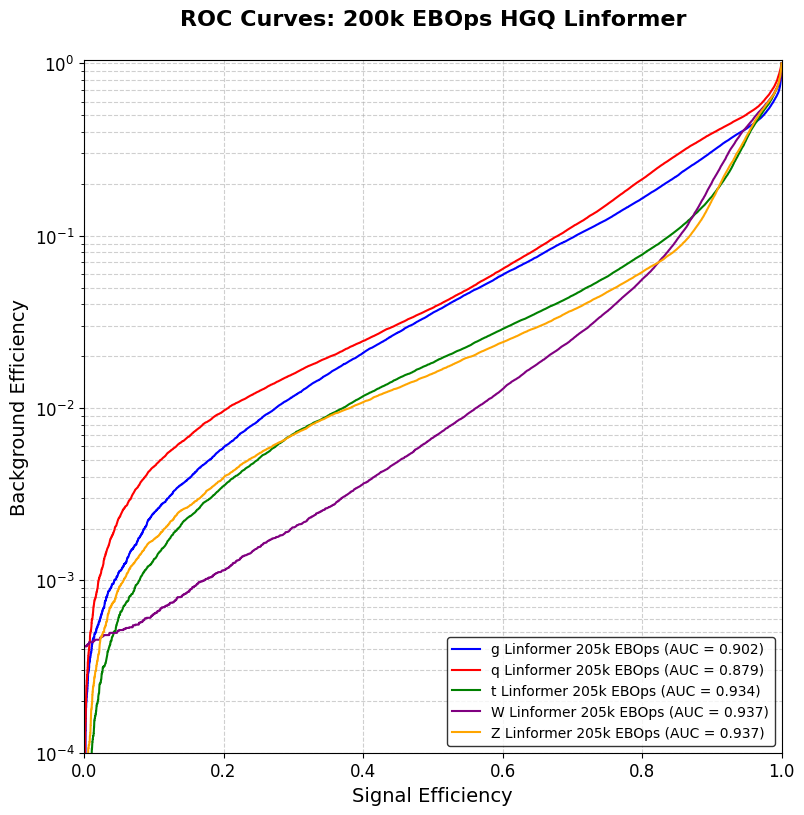

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. CRITICAL: Set JAX backend before importing Keras for HGQ compatibility
os.environ['KERAS_BACKEND'] = 'jax'
os.environ['JAX_PLATFORMS'] = 'cpu'

import keras
import hgq # Must be imported so Keras recognizes the custom Q layers

# 2. Load the model and evaluate
model_path = 'saved_models/qlinformer_jet_tagger_204969.keras'
print(f"Loading HGQ model from {model_path}...")
model = keras.models.load_model(model_path)

print("Evaluating accuracy on test set...")
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Accuracy: {accuracy:.4f}")

# Generate predictions
y_pred = model.predict(X_test, verbose=0)

# 3. Configure Matplotlib for the "academic" hls4ml look
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'legend.fontsize': 10, 
    'lines.linewidth': 1.5,
    'figure.figsize': (9, 9) 
})

# 4. Setup Plot
fig, ax = plt.subplots()
labels = ['g', 'q', 't', 'W', 'Z']
colors = ['blue', 'red', 'green', 'purple', 'orange']

for i, (label, color) in enumerate(zip(labels, colors)):
    # Calculate standard ML metrics
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred[:, i])
    auc_val = auc(fpr, tpr)
    
    # Plot Signal Efficiency (TPR) on X, Background Efficiency (FPR) on Y
    ax.plot(tpr, fpr, color=color, linestyle='-', 
             label=f'{label} Linformer 205k EBOps (AUC = {auc_val:.3f})')

# 5. HEP Specific Formatting (Log Scale)
ax.set_yscale('log')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0001, 1.05]) # Prevent crashing on 0

ax.set_xlabel('Signal Efficiency')
ax.set_ylabel('Background Efficiency')

plt.title('ROC Curves: 200k EBOps HGQ Linformer', pad=25, fontweight='bold')
plt.grid(True, which="both", linestyle='--', alpha=0.6) 

ax.legend(loc='lower right', frameon=True, edgecolor='black', ncol=1)

# Save high-res image and show
plt.savefig('Linformer_ROC_Curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Reset rcParams 
plt.rcdefaults()

In [14]:
import numpy as np

# Assuming 'model' is your loaded 205k EBOps model
total_weights = 0
zero_weights = 0

for layer in model.layers:
    # Get the weights for each layer
    weights = layer.get_weights()
    for w in weights:
        total_weights += w.size
        # Count how many weights were pushed exactly to 0
        zero_weights += np.sum(w == 0)

active_params = total_weights - zero_weights
sparsity = (zero_weights / total_weights) * 100

print(f"Total Structural Params: {total_weights}")
print(f"Active (Non-Zero) Params: {active_params}")
print(f"HGQ Sparsity: {sparsity:.2f}%")

Total Structural Params: 73480
Active (Non-Zero) Params: 70893
HGQ Sparsity: 3.52%
